In [1]:
from tqec.computation.prism import BasisPrism, Position3DHex, ZXPrism
from tqec.computation.pipe_prism import PrismPipeKind
from tqec.computation.prism_graph import PrismGraph
from tqec.computation.correlation import find_correlation_surfaces

import tqec.computation.syndrome_extraction_cc as se


import temp_utils

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

In [2]:
g = PrismGraph("CNOT")

prisms = [
    (Position3DHex(3,3,0), "ZN", "control-int"),
    (Position3DHex(3,3,1), "NN", ""),
    (Position3DHex(3,3,2), "NN", ""),
    (Position3DHex(3,3,3), "NZ", "control-out"),

    (Position3DHex(2,2,1), "XN", ""),
    (Position3DHex(2,2,2), "NZ", ""),

    (Position3DHex(1,3,0), "ZN", "target-in"),
    (Position3DHex(1,3,1), "NN", ""),
    (Position3DHex(1,3,2), "NN", ""),
    (Position3DHex(1,3,3), "NZ", "target-out"),

]

for pos, kind, label in prisms:
    g.add_prism(pos, kind, label)

#c temp
pipe_kind = PrismPipeKind(hor = BasisPrism.N, ver = BasisPrism.N)
g.add_pipe(prisms[0][0], prisms[1][0], pipe_kind)

pipe_kind = PrismPipeKind(hor = BasisPrism.N, ver = BasisPrism.N)
g.add_pipe(prisms[1][0], prisms[2][0], pipe_kind)

pipe_kind = PrismPipeKind(hor = BasisPrism.N, ver = BasisPrism.N)
g.add_pipe(prisms[2][0], prisms[3][0], pipe_kind)

#t temp
pipe_kind = PrismPipeKind(hor = BasisPrism.N, ver = BasisPrism.N)
g.add_pipe(prisms[6][0], prisms[7][0], pipe_kind)

pipe_kind = PrismPipeKind(hor = BasisPrism.N, ver = BasisPrism.N)
g.add_pipe(prisms[7][0], prisms[8][0], pipe_kind)

pipe_kind = PrismPipeKind(hor = BasisPrism.N, ver = BasisPrism.N)
g.add_pipe(prisms[8][0], prisms[9][0], pipe_kind)

#spatial pipes
pipe_kind = PrismPipeKind(hor = BasisPrism.X, ver = BasisPrism.Z)
g.add_pipe(prisms[1][0], prisms[4][0], pipe_kind)

pipe_kind = PrismPipeKind(hor = BasisPrism.Z, ver = BasisPrism.X)
g.add_pipe(prisms[8][0], prisms[5][0], pipe_kind)

#middle temp
pipe_kind = PrismPipeKind(hor = BasisPrism.N, ver = BasisPrism.N)
g.add_pipe(prisms[4][0], prisms[5][0], pipe_kind)

g.view_as_html()

In [3]:
zx = g.to_zx_graph()
correlation_surfaces = g.find_correlation_surfaces()
print("len correlation surfaces", len(correlation_surfaces))

idx = 1

cs = correlation_surfaces[idx]

#for single branch in red, construct by hand because automatic search does not give the exact desired one.
#from tqec.computation.correlation import (
#    CorrelationSurface,
#    ZXEdge,
#    ZXNode,
#)
#from tqec.utils.enums import Basis
#cs = CorrelationSurface(
#    frozenset({
#        ZXEdge(
#            ZXNode(6, Basis.X),
#            ZXNode(7, Basis.X),
#        ),
#        ZXEdge(
#            ZXNode(7, Basis.X),
#            ZXNode(8, Basis.X),
#        ),
#        ZXEdge(
#            ZXNode(8, Basis.X),
#            ZXNode(9, Basis.X),
#        ),
#    })
#)

print(cs)
horizontal_pipes_cs = g.find_ver_hor_correlation_surface(cs)

for key, val in horizontal_pipes_cs.items():
    print(key)
    print(val)
    print("===")

len correlation surfaces 2
CorrelationSurface(span=frozenset({ZXEdge(u=ZXNode(id=5, basis=Basis.Z), v=ZXNode(id=8, basis=Basis.Z)), ZXEdge(u=ZXNode(id=8, basis=Basis.Z), v=ZXNode(id=9, basis=Basis.Z)), ZXEdge(u=ZXNode(id=1, basis=Basis.Z), v=ZXNode(id=2, basis=Basis.Z)), ZXEdge(u=ZXNode(id=6, basis=Basis.Z), v=ZXNode(id=7, basis=Basis.Z)), ZXEdge(u=ZXNode(id=1, basis=Basis.Z), v=ZXNode(id=4, basis=Basis.Z)), ZXEdge(u=ZXNode(id=4, basis=Basis.Z), v=ZXNode(id=5, basis=Basis.Z)), ZXEdge(u=ZXNode(id=7, basis=Basis.Z), v=ZXNode(id=8, basis=Basis.Z)), ZXEdge(u=ZXNode(id=2, basis=Basis.Z), v=ZXNode(id=3, basis=Basis.Z))}))
PrismPipe(u=Prism(position=Position3DHex(x=2, y=2, z=2), kind=ZXPrism(prep=<BasisPrism.N: 'N'>, meas=<BasisPrism.Z: 'Z'>), label=''), v=Prism(position=Position3DHex(x=1, y=3, z=2), kind=ZXPrism(prep=<BasisPrism.N: 'N'>, meas=<BasisPrism.N: 'N'>), label=''), kind=PrismPipeKind(hor=<BasisPrism.Z: 'Z'>, ver=<BasisPrism.X: 'X'>, has_hadamard=False))
(<BasisPrism.Z: 'Z'>, 'ver')

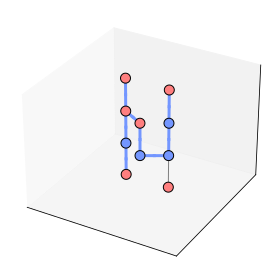

In [4]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from tqec.interop.pyzx.plot import draw_positioned_zx_graph_on, draw_correlation_surface_on


fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

draw_positioned_zx_graph_on(zx, ax, node_size=100)
draw_correlation_surface_on(cs, zx, ax)


In [5]:
#map correlation surface from zx to pipe diagram
vertex_ids = cs.span_vertices
positions_in_cs = {vid: zx.positions[vid] for vid in vertex_ids}

print("Positions involved in correlation surface:")
for vid, pos in positions_in_cs.items():
    print(f"  vertex {vid} → position {pos}")

# Then look up the actual cube objects in the block graph
prisms_in_cs = [prism for prism in g.prisms if prism.position in positions_in_cs.values()]
print("\nCubes involved:")
for cube in prisms_in_cs:
    print(f"  {cube.position}  kind={cube.kind}")

Positions involved in correlation surface:
  vertex 1 → position Position3DHex(x=3, y=3, z=1)
  vertex 2 → position Position3DHex(x=3, y=3, z=2)
  vertex 3 → position Position3DHex(x=3, y=3, z=3)
  vertex 4 → position Position3DHex(x=2, y=2, z=1)
  vertex 5 → position Position3DHex(x=2, y=2, z=2)
  vertex 6 → position Position3DHex(x=1, y=3, z=0)
  vertex 7 → position Position3DHex(x=1, y=3, z=1)
  vertex 8 → position Position3DHex(x=1, y=3, z=2)
  vertex 9 → position Position3DHex(x=1, y=3, z=3)

Cubes involved:
  Position3DHex(x=3, y=3, z=1)  kind=NN
  Position3DHex(x=3, y=3, z=2)  kind=NN
  Position3DHex(x=3, y=3, z=3)  kind=NZ
  Position3DHex(x=2, y=2, z=1)  kind=XN
  Position3DHex(x=2, y=2, z=2)  kind=NZ
  Position3DHex(x=1, y=3, z=0)  kind=ZN
  Position3DHex(x=1, y=3, z=1)  kind=NN
  Position3DHex(x=1, y=3, z=2)  kind=NN
  Position3DHex(x=1, y=3, z=3)  kind=NZ


stabilizer tests passed
stabilizer tests passed


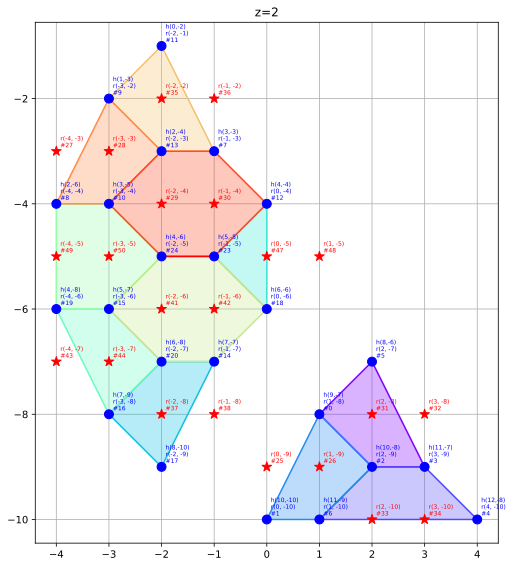

In [6]:
d=3
SE = se.SyndromeExtractionStimCC(g, d)
SE.retrieve_stabilizers_operators()
SE.reorder_all_stabilizers()
SE.meas_prep_data_qubits()
_ = SE.hex_mapping_to_quadratic()
mapping_full = SE.mapping_full

z_temp = 2
temp_utils.plot_mapping_full(mapping_full, z_temp)

test horizontal correlation surface construction

In [7]:

z=1

stabs_x, stabs_z, _, dct_single_type_stabs, dct_patch_stabilizers = SE.prism_graph.stabilizers_timeslice(z, SE.d)
result = SE.prism_graph.stabilizer_product_timeslice(z, SE.d, dct_single_type_stabs, dct_patch_stabilizers, testing = True)

stabilizer tests passed


In [8]:
d=7
rounds = d
p = 0.00


SE = se.SyndromeExtractionStimCC(g, d)
circuit = SE.run_all_superdense(
    rounds,
    p,
    p,
    p,
    p,
    cs = cs
)

stabilizer tests passed
stabilizer tests passed
horizontal_pipes_cs
PrismPipe(u=Prism(position=Position3DHex(x=2, y=2, z=2), kind=ZXPrism(prep=<BasisPrism.N: 'N'>, meas=<BasisPrism.Z: 'Z'>), label=''), v=Prism(position=Position3DHex(x=1, y=3, z=2), kind=ZXPrism(prep=<BasisPrism.N: 'N'>, meas=<BasisPrism.N: 'N'>), label=''), kind=PrismPipeKind(hor=<BasisPrism.Z: 'Z'>, ver=<BasisPrism.X: 'X'>, has_hadamard=False))
PrismPipe(u=Prism(position=Position3DHex(x=2, y=2, z=1), kind=ZXPrism(prep=<BasisPrism.X: 'X'>, meas=<BasisPrism.N: 'N'>), label=''), v=Prism(position=Position3DHex(x=3, y=3, z=1), kind=ZXPrism(prep=<BasisPrism.N: 'N'>, meas=<BasisPrism.N: 'N'>), label=''), kind=PrismPipeKind(hor=<BasisPrism.X: 'X'>, ver=<BasisPrism.Z: 'Z'>, has_hadamard=False))
========================z=0=======================
stabtype XZ, Z stab
entries []
stabtype XZ, Z stab
entries [PositionEntry(hex=Position3DHex(x=22, y=-22, z=0), rect=(0, -22), label=3), PositionEntry(hex=Position3DHex(x=23, y=-21, z=0)

In [9]:
for z in SE.z_values:
    print(f"z={z}")
    result = SE.result_dct[z]["product"]
    stabilizer_products_x = result.stabilizer_products_x
    stabilizer_products_z = result.stabilizer_products_z
    print("len x product", len(stabilizer_products_x))
    print("len z product", len(stabilizer_products_z))

z=0
len x product 0
len z product 0
z=1
len x product 0
len z product 1
z=2
len x product 1
len z product 0
z=3
len x product 0
len z product 0


In [10]:
svg = circuit.diagram("timeline-svg")
with open(f"circuit_bell_CNOT_d{d}.svg", "w") as f:
    f.write(str(svg))

In [11]:
N=100
# sample the logical observable directly
sampler = circuit.compile_sampler()
samples = sampler.sample(shots=N)
#print(samples)  # should be all the same value

# alternatively, use the detector sampler to check no detectors fire
det_sampler = circuit.compile_detector_sampler()
det_results, obs_results = det_sampler.sample(shots=N, separate_observables=True)
print("Any detectors fired?", det_results.any())   # should be False         
#print(det_results)

fired = det_results.any(axis=0)  # shape: (n_detectors,)
fired_indices = np.where(fired)[0]

print("Detectors that fired:", fired_indices)
for idx in fired_indices:
    print(f"  D{idx}: fired in {det_results[:, idx].sum()}/{N} shots")

Any detectors fired? False
Detectors that fired: []


In [12]:
dem = circuit.detector_error_model()

In [13]:
dem = circuit.detector_error_model()
import stim

for instruction in dem.flattened():
    if instruction.type == "error":
        detectors = [t for t in instruction.targets_copy() 
                     if t.is_relative_detector_id()]
        logicals = [t for t in instruction.targets_copy() 
                    if t.is_logical_observable_id()]
        
        if len(detectors) == 0:
            print(f"Undetected error (p={instruction.args_copy()[0]}):")
            print(f"  Flips observables: {logicals}")
            print(f"  Full instruction: {instruction}")
def resolve_rec_indices(missing_det_circuit, total_measurements):
    detectors = []
    
    for inst in missing_det_circuit.flattened():
        targets = [
            total_measurements + target.value
            for target in inst.targets_copy()
            if target.is_measurement_record_target
        ]
        if targets:
            detectors.append(targets)
    
    return detectors

# Usage:
res = circuit.missing_detectors(unknown_input=False)

detectors = resolve_rec_indices(res, circuit.num_measurements)
for i, d in enumerate(detectors):
    print(f"Detector {i}: {d}")

Detector 0: [2684, 2685, 2687, 2688, 2689, 2694, 2699, 2700, 2701]


## example with surface code

https://tqec.github.io/tqec/user_guide/quick_start.html

In [34]:
from tqec import BlockGraph
from tqec.gallery.cnot import cnot
from tqec import Basis

block_graph = cnot(Basis.X)

correlation_surfaces = block_graph.find_correlation_surfaces()

block_graph.view_as_html()

In [44]:
from tqec import compile_block_graph


idx_obs = 1
compiled_computation = compile_block_graph(block_graph, observables=[correlation_surfaces[idx_obs]])

In [40]:
from tqec import NoiseModel

circuit = compiled_computation.generate_stim_circuit(
    k=1,
    noise_model=NoiseModel.uniform_depolarizing(0.001),
)

In [45]:
zx = block_graph.to_zx_graph()
cs = correlation_surfaces[idx_obs]

# Get the vertex IDs in the correlation surface
vertex_ids = cs.span_vertices  # set[int]

# Map each vertex ID back to its 3D position (= cube/prism position)
positions_in_cs = {vid: zx.positions[vid] for vid in vertex_ids}

print("Positions involved in correlation surface:")
for vid, pos in positions_in_cs.items():
    print(f"  vertex {vid} → position {pos}")

# Then look up the actual cube objects in the block graph
cubes_in_cs = [cube for cube in block_graph.cubes if cube.position in positions_in_cs.values()]
print("\nCubes involved:")
for cube in cubes_in_cs:
    print(f"  {cube.position}  kind={cube.kind}")

Positions involved in correlation surface:
  vertex 0 → position (0,0,0)
  vertex 1 → position (0,0,1)
  vertex 2 → position (0,0,2)
  vertex 3 → position (0,0,3)
  vertex 4 → position (0,1,1)
  vertex 5 → position (0,1,2)
  vertex 8 → position (1,1,2)
  vertex 9 → position (1,1,3)

Cubes involved:
  (0,0,0)  kind=ZXX
  (0,0,1)  kind=ZXX
  (0,0,2)  kind=ZXZ
  (0,0,3)  kind=ZXX
  (0,1,1)  kind=ZXX
  (0,1,2)  kind=ZXZ
  (1,1,2)  kind=ZXZ
  (1,1,3)  kind=ZXX


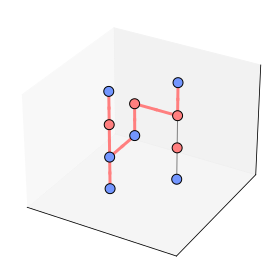

In [46]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from tqec.interop.pyzx.plot import draw_positioned_zx_graph_on, draw_correlation_surface_on


fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

draw_positioned_zx_graph_on(zx, ax, node_size=100)
draw_correlation_surface_on(cs, zx, ax)


In [36]:
from multiprocessing import cpu_count
import numpy as np
from pathlib import Path

from tqec import NoiseModel
from tqec.simulation.simulation import start_simulation_using_sinter


# returns a iterator
stats = start_simulation_using_sinter(
    block_graph,
    ks=range(1, 4),  # k values for the code distance
    ps=list(np.logspace(-4, -1, 10)),  # error rates
    noise_model_factory=NoiseModel.uniform_depolarizing,  # noise model
    manhattan_radius=2,  # parameter for automatic detector computation
    observables=[correlation_surfaces[1]],  # observable of interest
    decoders=["pymatching"],
    num_workers=cpu_count(),
    max_shots=1_000_000,
    max_errors=400,
    save_resume_filepath=Path("./_examples_database/quick_start.csv"),
    database_path=Path("./_examples_database/database.pkl"),
)

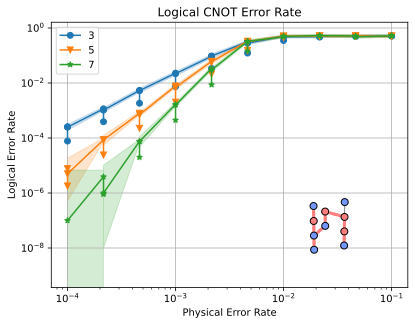

In [38]:
import matplotlib.pyplot as plt
import sinter

from tqec.simulation.plotting.inset import plot_observable_as_inset

zx_graph = block_graph.to_zx_graph()

fig, ax = plt.subplots()
# len(stats) = 1 if we have multiple we can iterate over the results
sinter.plot_error_rate(
    ax=ax,
    stats=next(iter(stats)),
    x_func=lambda stat: stat.json_metadata["p"],
    group_func=lambda stat: stat.json_metadata["d"],
)
plot_observable_as_inset(ax, zx_graph, correlation_surfaces[idx_obs])
ax.grid(axis="both")
ax.legend()
ax.loglog()
ax.set_title("Logical CNOT Error Rate")
ax.set_xlabel("Physical Error Rate")
ax.set_ylabel("Logical Error Rate")
plt.show()